In [7]:
import os
import glob
import pandas as pd

# Define paths
part1_path = '/content/drive/MyDrive/CVR_project/HAM10000_images_part_1'
part2_path = '/content/drive/MyDrive/CVR_project/HAM10000_images_part_2'
metadata_path = '/content/drive/MyDrive/CVR_project/HAM10000_metadata.csv'
NUM_IMAGES = 200





In [10]:
metadata = pd.read_csv('/content/drive/MyDrive/CVR_project/HAM10000_metadata.csv')
all_images = glob.glob(os.path.join(part1_path, '*.jpg')) + glob.glob(os.path.join(part2_path, '*.jpg'))
all_images = all_images[:NUM_IMAGES]

valid_ids = {os.path.basename(p).split('.')[0] for p in all_images}
metadata = metadata[metadata['image_id'].isin(valid_ids)]

benign_labels = ['nv', 'bkl', 'df', 'vasc']
malignant_labels = ['mel', 'bcc', 'akiec']

metadata['label'] = metadata['dx'].apply(lambda x: 'benign' if x in benign_labels else 'malignant')
metadata['label_num'] = metadata['label'].map({'benign': 0, 'malignant': 1})

print("Label Distribution:\n", metadata['label'].value_counts())

Label Distribution:
 label
benign       164
malignant     36
Name: count, dtype: int64


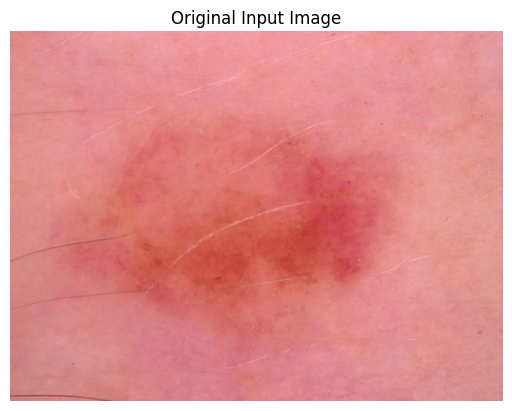

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load original image
img_path = all_images[4]
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Save for presentation
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Original Input Image")
plt.savefig("original_input_image.png", bbox_inches='tight')
plt.show()


In [12]:
metadata = pd.read_csv(metadata_path)
all_images = glob.glob(os.path.join(part1_path, '*.jpg')) + glob.glob(os.path.join(part2_path, '*.jpg'))
all_images = all_images[:NUM_IMAGES]

valid_ids = {os.path.basename(p).split('.')[0] for p in all_images}
metadata = metadata[metadata['image_id'].isin(valid_ids)]

benign_labels = ['nv', 'bkl', 'df', 'vasc']
malignant_labels = ['mel', 'bcc', 'akiec']

metadata['label'] = metadata['dx'].apply(lambda x: 'benign' if x in benign_labels else 'malignant')
metadata['label_num'] = metadata['label'].map({'benign': 0, 'malignant': 1})

print("Label Distribution:\n", metadata['label'].value_counts())



Label Distribution:
 label
benign       164
malignant     36
Name: count, dtype: int64


In [18]:
def segment_lesion_fast(img):
    # 1. Convert to YCrCb space and isolate the Cr channel
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    _, cr, _ = cv2.split(ycrcb)

    # 2. Smooth and threshold
    blur = cv2.GaussianBlur(cr, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Fill in tiny inner holes first
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 4. CRITICAL FIX: Find all shapes and keep ONLY the biggest one
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        # Identify the contour with the largest surface area
        largest_contour = max(contours, key=cv2.contourArea)

        # Build a completely empty black mask matching the image dimensions
        clean_mask = np.zeros_like(mask)

        # Draw ONLY the largest shape onto the new clean mask as solid white
        cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
        mask = clean_mask

    # 5. Extract the pristine segmented image region
    seg = cv2.bitwise_and(img, img, mask=mask)
    seg = cv2.resize(seg, (IMG_SIZE, IMG_SIZE))
    return seg


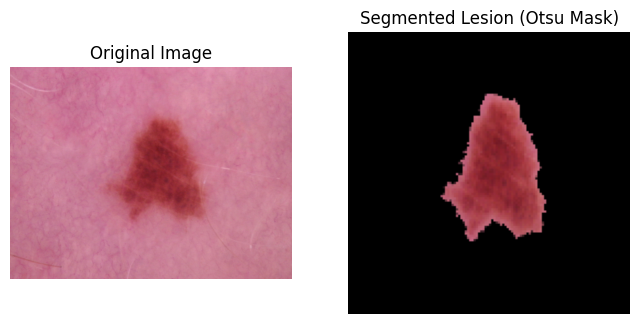

In [19]:
sample_path = all_images[5]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
seg_img = segment_lesion_fast(img)
seg_rgb = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(seg_rgb)
plt.title("Segmented Lesion (Otsu Mask)")
plt.axis("off")
plt.show()


In [20]:
# Load Images into Arrays
X, y = [], []
for p in all_images:
    img = cv2.imread(p)
    if img is None: continue
    seg = segment_lesion_fast(img)
    X.append(seg)
    img_id = os.path.basename(p).split('.')[0]
    y.append(metadata.loc[metadata['image_id']==img_id, 'label_num'].values[0])

X = np.array(X).astype('float32') / 255.0
y = np.array(y)

print("Images loaded:", X.shape)


Images loaded: (200, 128, 128, 3)


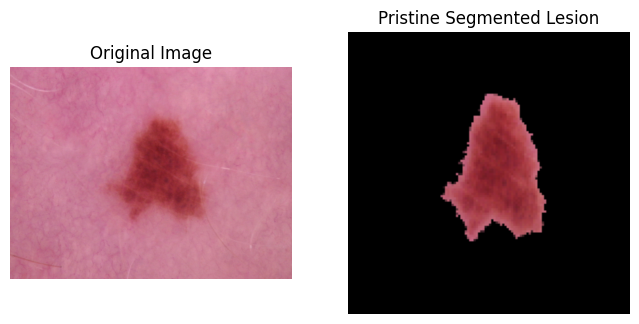

In [21]:
# Select a sample image to test your updated function
sample_path = all_images[5]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


seg_img = segment_lesion_fast(img)
seg_rgb = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(seg_rgb)
plt.title("Pristine Segmented Lesion")
plt.axis("off")
plt.show()


In [22]:
X, y = [], []

for p in all_images:
    img = cv2.imread(p)
    if img is None:
        continue


    seg = segment_lesion_fast(img)
    X.append(seg)

    # Safely extract image ID and search metadata matching the ID
    img_id = os.path.basename(p).split('.')[0]
    matched_label = metadata.loc[metadata['image_id'] == img_id, 'label_num']

    if not matched_label.empty:
        y.append(matched_label.values[0])
    else:

        y.append(0)

# Normalize pixel vectors and transform to arrays
X = np.array(X).astype('float32') / 255.0
y = np.array(y)

print("Images successfully processed and array loaded:", X.shape)
print("Labels array shape loaded:", y.shape)


Images successfully processed and array loaded: (200, 128, 128, 3)
Labels array shape loaded: (200,)


In [23]:
from sklearn.model_selection import train_test_split


base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
output = Dense(2, activation='softmax')(x)
model = Model(base.input, output)

# Compile framework
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Training MobileNetV2 Classifier...")
history = model.fit(X_train, y_train, epochs=3, batch_size=16, validation_data=(X_test, y_test))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training MobileNetV2 Classifier...
Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 580ms/step - accuracy: 0.7563 - loss: 0.7347 - val_accuracy: 0.8250 - val_loss: 0.5463
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.8188 - loss: 0.4808 - val_accuracy: 0.7500 - val_loss: 0.5252
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.8125 - loss: 0.4119 - val_accuracy: 0.8250 - val_loss: 0.4160


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
Model Accuracy Evaluation: 0.825

Classification Report:
               precision    recall  f1-score   support

      benign       0.85      0.97      0.90        34
   malignant       0.00      0.00      0.00         6

    accuracy                           0.82        40
   macro avg       0.42      0.49      0.45        40
weighted avg       0.72      0.82      0.77        40



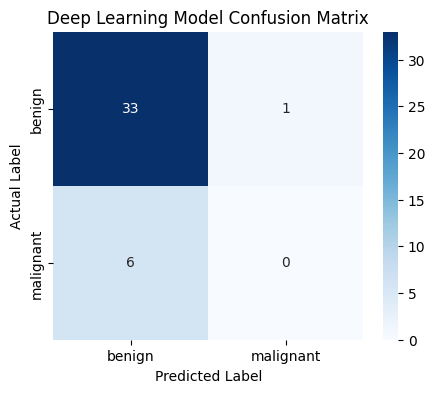

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = np.argmax(model.predict(X_test), axis=1)

print("Model Accuracy Evaluation:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
plt.title("Deep Learning Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


In [25]:
def calc_area(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, t = cv2.threshold(g, 1, 255, cv2.THRESH_BINARY)
    return cv2.countNonZero(t)

def calc_mean_color(img):
    mask = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) > 0
    return np.array(cv2.mean(img, mask.astype(np.uint8))[:3])

# Calculate average baseline values for benign vs malignant clusters
training_feats = {}
for cls, n in [('benign', 0), ('malignant', 1)]:
    imgs = X[y == n]
    areas = [calc_area((img * 255).astype(np.uint8)) for img in imgs]
    colors = [calc_mean_color((img * 255).astype(np.uint8)) for img in imgs]
    training_feats[n] = {'area': np.mean(areas), 'color': np.mean(colors, axis=0)}

# Calculate deviations using fixed absolute distance parameters
results = []
for img_arr, true_label in zip(X, y):
    area = calc_area((img_arr * 255).astype(np.uint8))
    color = calc_mean_color((img_arr * 255).astype(np.uint8))
    c = true_label

    # Absolute value calculation fixes the negative shrinkage bug
    da = abs(((area - training_feats[c]['area']) / (training_feats[c]['area'] + 1e-9)) * 100)
    dc = np.mean(np.abs(color - training_feats[c]['color']))

    # Structural risk fallback filtering rule assignments
    if da > 25 or dc > 20:
        r = 'High'
    elif da > 10 or dc > 10:
        r = 'Medium'
    else:
        r = 'Low'

    results.append({'Δarea': da, 'Δcolor': dc, 'risk': r, 'true': 'benign' if c == 0 else 'malignant'})

df = pd.DataFrame(results)
print("Calculated Risk Groupings:\n", df['risk'].value_counts())
df.head()


Calculated Risk Groupings:
 risk
High      170
Medium     26
Low         4
Name: count, dtype: int64


,Δarea,Δcolor,risk,true
0,20.803682,28.791540,High,benign
1,63.084315,5.724830,High,benign
2,45.450685,15.951242,High,malignant
3,34.978147,20.437305,High,benign
4,4.317193,15.138679,Medium,benign


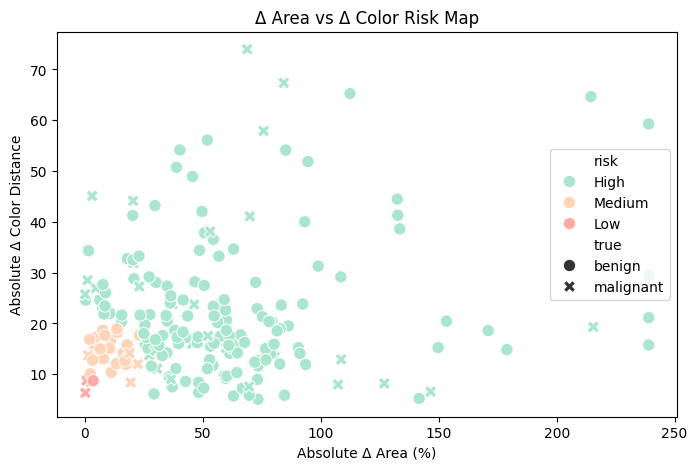

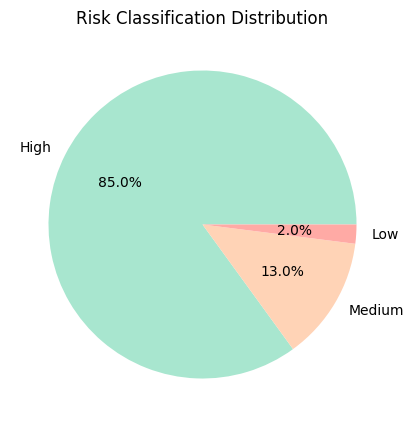

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Δarea', y='Δcolor', hue='risk', style='true', s=80, palette=['#a8e6cf','#ffd3b6','#ffaaa5'])
plt.title("Δ Area vs Δ Color Risk Map")
plt.xlabel("Absolute Δ Area (%)")
plt.ylabel("Absolute Δ Color Distance")
plt.show()

# Pie chart – Risk distribution
plt.figure(figsize=(5, 5))
df['risk'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#a8e6cf', '#ffd3b6', '#ffaaa5'])
plt.title("Risk Classification Distribution")
plt.ylabel("")
plt.show()


In [27]:
from sklearn.ensemble import RandomForestClassifier


risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
inv_risk_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
df['risk_encoded'] = df['risk'].map(risk_mapping)


X_rf = df[['Δarea', 'Δcolor']]
y_rf = df['risk_encoded']


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Build and train your Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)


y_pred_rf = rf_model.predict(X_test_rf)
print("Random Forest Classifier Evaluation Report:\n")
print(classification_report(y_test_rf, y_pred_rf, target_names=['Low', 'Medium', 'High']))


Random Forest Classifier Evaluation Report:

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.60      0.75         5
        High       0.97      1.00      0.99        35

    accuracy                           0.95        40
   macro avg       0.66      0.53      0.58        40
weighted avg       0.98      0.95      0.96        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


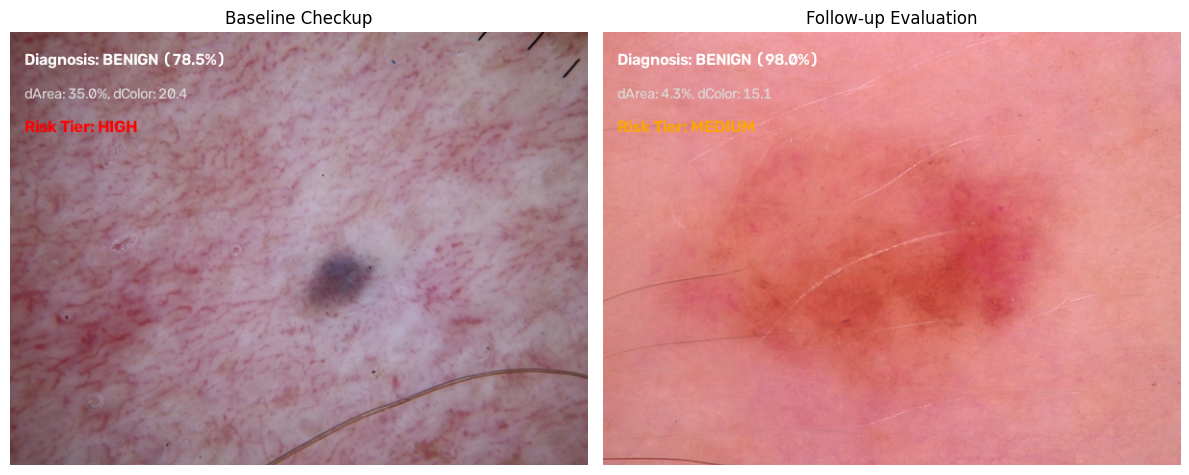

In [34]:
def visualize_before_after_overlay(baseline_path, followup_path, train_feats, dl_model, rf_classifier):
    def process(img_path):
        img = cv2.imread(img_path)
        seg = segment_lesion_fast(img)

        # Deep Learning diagnostic inference prediction
        x = np.expand_dims(seg.astype('float32') / 255.0, 0)
        prob = dl_model.predict(x)
        c = int(np.argmax(prob))
        lbl = 'benign' if c == 0 else 'malignant'

        # Mathematical property calculations
        area = calc_area(seg)
        color = calc_mean_color(seg)

        # Distance calculation
        da = abs(((area - train_feats[c]['area']) / (train_feats[c]['area'] + 1e-9)) * 100)
        dc = np.mean(np.abs(color - train_feats[c]['color']))

        # analysis prediction
        features_input = pd.DataFrame([{'Δarea': da, 'Δcolor': dc}])
        risk_encoded_pred = rf_classifier.predict(features_input)[0]
        risk = inv_risk_mapping[risk_encoded_pred]

        return img, lbl, prob[0][c], da, dc, risk

    # Process files
    base_img, base_lbl, base_prob, base_da, base_dc, base_risk = process(baseline_path)
    follow_img, follow_lbl, follow_prob, follow_da, follow_dc, follow_risk = process(followup_path)

    def overlay_text(img, lbl, prob, da, dc, risk):
        overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label_text = f"Diagnosis: {lbl.upper()} ({prob*100:.1f}%)"
        stats_text = f"dArea: {da:.1f}%, dColor: {dc:.1f}"
        risk_text = f"Risk Tier: {risk.upper()}"


        color_map = {'Low': (0, 255, 0), 'Medium': (255, 165, 0), 'High': (255, 0, 0)}
        text_color = color_map.get(risk, (255, 255, 255))

        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(overlay, label_text, (15, 35), font, 0.55, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(overlay, stats_text, (15, 70), font, 0.50, (220, 220, 220), 1, cv2.LINE_AA)
        cv2.putText(overlay, risk_text, (15, 105), font, 0.60, text_color, 2, cv2.LINE_AA)
        return overlay

    out_base = overlay_text(base_img, base_lbl, base_prob, base_da, base_dc, base_risk)
    out_follow = overlay_text(follow_img, follow_lbl, follow_prob, follow_da, follow_dc, follow_risk)


    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(out_base)
    plt.title("Baseline Checkup")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(out_follow)
    plt.title("Follow-up Evaluation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



visualize_before_after_overlay(all_images[3], all_images[4], training_feats, model, rf_model)


Generating final clinical decision support tracking visualization...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


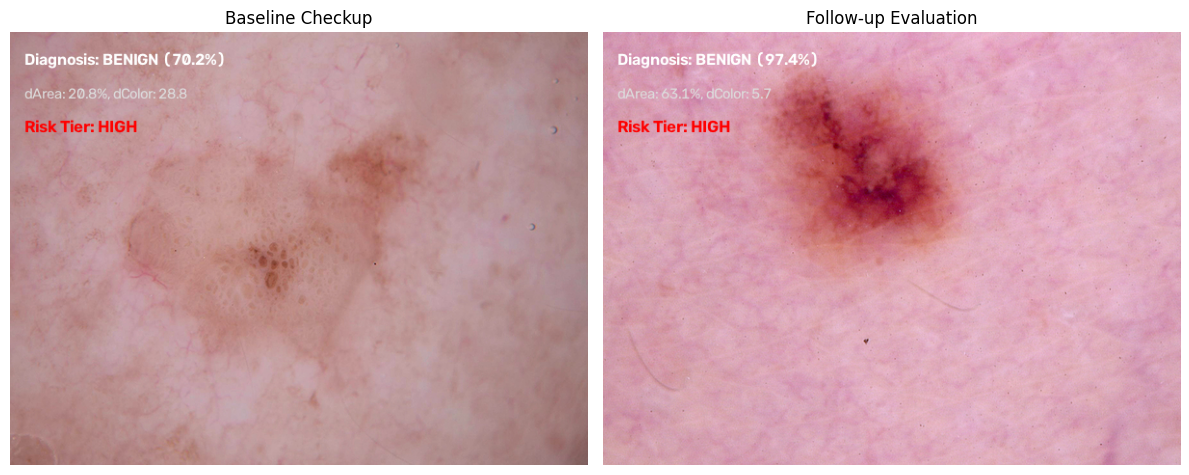

In [32]:
# 1. Pick a baseline image and a follow-up image to simulate tracking a patient over time
baseline_sample = all_images[0]
followup_sample = all_images[1]

print("Generating final clinical decision support tracking visualization...")

# 2. Call your overlay function using the trained models and baseline stats
visualize_before_after_overlay(
    baseline_path=baseline_sample,
    followup_path=followup_sample,
    train_feats=training_feats,
    dl_model=model,
    rf_classifier=rf_model
)
